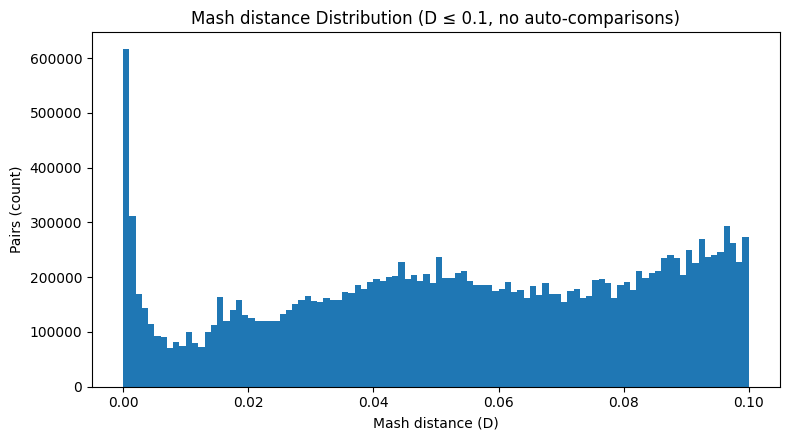

Resumen:
  Pares muy parecidos (D ≤ 0.1): 18139380
  D min = 0.000000, D max = 0.100000, media = 0.054184
  P50 = 0.055160, P90 = 0.092947, P95 = 0.096496, P99 = 0.099362

Tabla de histograma guardada en: mash_distance_histogram_similar_le0.1.csv


In [1]:
# Distribución de Mash distance para pares muy parecidos (>90% identidad ≈ D <= 0.1)
# - Lectura en streaming (RAM-safe)
# - Excluye autocomparaciones (q == r)
# - Rango del histograma: [0.0, 0.1] (100 bins)
# - Exporta tabla de bins a CSV

from pathlib import Path
import gzip
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Rutas ===
DIST_PATH = Path("/home/nacho/HDD16/Nacho/RepliCOOC/derep/mash_dist.nozero.tsv")
OUT_CSV   = Path("mash_distance_histogram_similar_le0.1.csv")

# === Parámetros ===
MAX_D   = 0.1     # D <= 0.1 ~ >90% identidad (aprox.)
BINS    = 100
EXCLUIR_AUTOS = True  # descartar líneas q==r (autocomparación)

def open_maybe_gzip(p: Path):
    return gzip.open(p, "rt") if str(p).endswith(".gz") else open(p, "r")

def stream_values_le_threshold(path: Path, max_d: float = 0.1, excluir_autos: bool = True):
    """Devuelve un array de distancias D<=max_d (excluyendo autocomparaciones si se pide)."""
    vals = []
    with open_maybe_gzip(path) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                parts = line.split()
            if len(parts) < 3:
                continue
            q, r = parts[0], parts[1]
            try:
                d = float(parts[2])
            except Exception:
                continue
            if excluir_autos and q == r:
                continue
            if d <= max_d:
                vals.append(d)
    return np.array(vals, dtype=float)

# --- Leer valores D <= 0.1 (sin autocomparaciones) ---
dists = stream_values_le_threshold(DIST_PATH, MAX_D, EXCLUIR_AUTOS)

# --- Resumen y guardado de histograma ---
if dists.size == 0:
    print("No se encontraron pares con D <= 0.1 (y excluyendo autocomparaciones).")
else:
    # Histograma en [0, 0.1]
    edges = np.linspace(0.0, MAX_D, BINS + 1)
    counts, _ = np.histogram(dists, bins=edges)
    centers = (edges[:-1] + edges[1:]) / 2.0

    # Guardar tabla
    pd.DataFrame({
        "bin_left":  edges[:-1],
        "bin_right": edges[1:],
        "bin_center": centers,
        "count": counts
    }).to_csv(OUT_CSV, index=False)

    # Plot
    plt.figure(figsize=(8, 4.5))
    plt.bar(centers, counts, width=(edges[1]-edges[0]))
    plt.xlabel("Mash distance (D)")
    plt.ylabel("Pairs (count)")
    plt.title("Mash distance Distribution (D ≤ 0.1, no auto-comparisons)")
    plt.tight_layout()
    plt.show()

    # Stats útiles
    perc = np.percentile(dists, [50, 90, 95, 99])
    print("Resumen:")
    print(f"  Pares muy parecidos (D ≤ {MAX_D}): {dists.size}")
    print(f"  D min = {dists.min():.6f}, D max = {dists.max():.6f}, media = {dists.mean():.6f}")
    print(f"  P50 = {perc[0]:.6f}, P90 = {perc[1]:.6f}, P95 = {perc[2]:.6f}, P99 = {perc[3]:.6f}")
    print(f"\nTabla de histograma guardada en: {OUT_CSV}")


In [1]:
# ================================================================
# Louvain por nivel (incluye nodos aislados)
# - Niveles de /derep/plasmid_replicons.tsv  (level = max(n_replicons, len(replicon_types)))
# - Aristas si D <= 0.01 a partir de /derep/mash_dist.nozero.tsv
# - Louvain por nivel; cada aislado es su propio clúster
# - Representante por clúster: mayor tamaño (size_bp -> AA sum -> bytes)
# Salidas en: /derep/louvain_by_level_from_table_including_isolates
# ================================================================
from pathlib import Path
import os, gzip, csv
from collections import defaultdict
import pandas as pd
import networkx as nx
from community import community_louvain  # pip install python-louvain

# -------------------- Rutas --------------------
BASE       = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
REPL_TSV   = BASE / "derep/plasmid_replicons.tsv"
DIST_PATH  = BASE / "derep/mash_dist.nozero.tsv"   # col3 = D
OUT_DIR    = BASE / "derep/louvain_by_level_from_table_including_isolates"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- Parámetros --------------------
D_THRESH     = 0.01
EXCLUDE_SELF = True

# -------------------- Helpers --------------------
def open_maybe_gzip(p: Path):
    return gzip.open(p, "rt") if str(p).endswith(".gz") else open(p, "r")

def norm_id(x: str) -> str:
    x = os.path.basename(str(x).strip())
    for ext in (".faa",".fa",".fna",".fasta",".gz"):
        if x.endswith(ext): x = x[:-len(ext)]
    return x

def tokens_csv(s: str):
    if not isinstance(s, str) or not s.strip(): return []
    return [t.strip() for t in s.split(",") if t.strip()]

def aa_length_from_faa(faa_path: Path) -> int:
    try:
        if not faa_path or not faa_path.exists(): return -1
        total, cur = 0, 0
        with open(faa_path, "r") as fh:
            for line in fh:
                if not line: continue
                if line.startswith(">"):
                    total += cur; cur = 0
                else:
                    cur += len(line.strip())
        total += cur
        return total if total > 0 else -1
    except Exception:
        return -1

def file_bytes(p: Path) -> int:
    try: return p.stat().st_size
    except Exception: return 0

# -------------------- Cargar y calcular niveles --------------------
assert REPL_TSV.exists(), f"No existe {REPL_TSV}"
rep = pd.read_csv(REPL_TSV, sep="\t", dtype=str)

need = {"plasmid_id","replicon_types","faa","size_bp","n_replicons"}
missing = need - set(rep.columns)
if missing:
    raise SystemExit(f"Faltan columnas: {sorted(missing)}")

rep["plasmid_id"] = rep["plasmid_id"].astype(str)
rep["faa"]        = rep["faa"].astype(str)
rep["n_replicons"] = pd.to_numeric(rep["n_replicons"], errors="coerce").fillna(0).astype(int)
rep["n_from_types"] = rep["replicon_types"].apply(lambda s: len(tokens_csv(s)))
rep["level"] = rep[["n_replicons","n_from_types"]].max(axis=1)
rep["size_bp"] = pd.to_numeric(rep["size_bp"], errors="coerce")

# Quitamos nivel 0
rep = rep[rep["level"] > 0].copy()
levels = sorted(rep["level"].unique().tolist())
print(f"[INFO] Niveles: {levels} | N (sin nivel 0) = {rep.shape[0]}")

# Mapeos
id2level  = dict(zip(rep["plasmid_id"], rep["level"]))
id2faa    = {pid: Path(f) if isinstance(f, str) and f.strip() else None
             for pid, f in zip(rep["plasmid_id"], rep["faa"])}
id2sizebp = dict(zip(rep["plasmid_id"], rep["size_bp"]))

# Tamaño métrico: size_bp -> AA sum -> bytes
size_cache = {}
def size_metric(pid: str) -> int:
    if pid in size_cache: return size_cache[pid]
    s_bp = id2sizebp.get(pid, None)
    if pd.notna(s_bp) and float(s_bp) > 0:
        size_cache[pid] = int(float(s_bp)); return size_cache[pid]
    faa = id2faa.get(pid)
    aa = aa_length_from_faa(faa) if faa else -1
    if aa >= 0:
        size_cache[pid] = aa; return aa
    size_cache[pid] = file_bytes(faa) if faa else 0
    return size_cache[pid]

# -------------------- Construir grafos por nivel (añadir TODOS los nodos) --------------------
graphs = {lvl: nx.Graph() for lvl in levels}
for lvl in levels:
    ids_lvl = rep.loc[rep["level"]==lvl, "plasmid_id"].tolist()
    graphs[lvl].add_nodes_from(ids_lvl)

# -------------------- Añadir ARISTAS (streaming mash_dist, D <= 0.01, mismo nivel) --------------------
stats = dict(total=0, kept=0, skipped_self=0, skipped_thresh=0, skipped_unknown=0, skipped_diff=0, skipped_fmt=0)
assert DIST_PATH.exists(), f"No existe {DIST_PATH}"

with open_maybe_gzip(DIST_PATH) as fh:
    for line in fh:
        stats["total"] += 1
        line = line.strip()
        if not line: continue
        parts = line.split("\t")
        if len(parts) < 3: parts = line.split()
        if len(parts) < 3:
            stats["skipped_fmt"] += 1; continue
        q_raw, r_raw, d_raw = parts[0], parts[1], parts[2]
        try:
            d = float(d_raw)
        except Exception:
            stats["skipped_fmt"] += 1; continue
        if EXCLUDE_SELF and q_raw == r_raw:
            stats["skipped_self"] += 1; continue
        if d > D_THRESH:
            stats["skipped_thresh"] += 1; continue
        q, r = norm_id(q_raw), norm_id(r_raw)
        lv_q, lv_r = id2level.get(q), id2level.get(r)
        if lv_q is None or lv_r is None:
            stats["skipped_unknown"] += 1; continue
        if lv_q != lv_r:
            stats["skipped_diff"] += 1; continue
        graphs[lv_q].add_edge(q, r, weight=1.0 - d)
        stats["kept"] += 1

print("[BUILD] Stats:", stats)
for lvl in levels:
    G = graphs[lvl]
    deg0 = sum(1 for n,deg in G.degree() if deg==0)
    print(f"  Level {lvl}: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, aislados={deg0}")

# -------------------- Louvain por nivel (incluye aislados) --------------------
assignments = []       # (id, level, cluster)
representatives = []   # (level, cluster, representative, rep_size, cluster_size)

for lvl in levels:
    G = graphs[lvl]
    if G.number_of_nodes() == 0: continue
    print(f"[LOUVAIN] Nivel {lvl}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas...")
    # Partición Louvain ponderada
    part = community_louvain.best_partition(G, weight='weight')
    # Asegurar que TODOS los nodos están en part (incl. aislados por si acaso)
    next_cid = (max(part.values()) + 1) if part else 0
    for n in G.nodes():
        if n not in part:
            part[n] = next_cid
            next_cid += 1
    # Agrupar por cluster
    clusters = defaultdict(list)
    for node, cid in part.items():
        clusters[cid].append(node)
        assignments.append((node, lvl, cid))
    # Elegir representante por cluster (incluye aislados)
    for cid, members in clusters.items():
        rep_id = sorted(members, key=lambda x: (-size_metric(x), x))[0]
        representatives.append((lvl, cid, rep_id, size_metric(rep_id), len(members)))

# -------------------- Salidas --------------------
assign_path = OUT_DIR / "cluster_assignments_by_level.tsv"
repr_path   = OUT_DIR / "representatives_by_cluster_level.tsv"
keep_path   = OUT_DIR / "to_keep_louvain_by_level.txt"

with open(assign_path, "w", newline="") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["id","level","cluster"])
    for row in sorted(assignments, key=lambda x: (x[1], x[2], x[0])):
        w.writerow(row)

with open(repr_path, "w", newline="") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["level","cluster","representative","rep_size_metric","cluster_size"])
    for row in sorted(representatives, key=lambda x: (x[0], x[1])):
        w.writerow(row)

with open(keep_path, "w") as f:
    for lvl, cid, rep_id, *_ in sorted(representatives, key=lambda x: (x[0], x[1], x[2])):
        f.write(rep_id + "\n")

print(f"[OUT] {assign_path}")
print(f"[OUT] {repr_path}")
print(f"[OUT] {keep_path}")
print(f"[SUMMARY] niveles={len(levels)} | clusters={len(representatives)} | reps={len(representatives)}")


[INFO] Niveles: [1, 2, 3, 4, 5, 6, 7, 8] | N (sin nivel 0) = 53515
[BUILD] Stats: {'total': 693305513, 'kept': 1544510, 'skipped_self': 72536, 'skipped_thresh': 691465255, 'skipped_unknown': 44446, 'skipped_diff': 178766, 'skipped_fmt': 0}
  Level 1: nodes=37017, edges=589080, aislados=12758
  Level 2: nodes=9225, edges=92134, aislados=3529
  Level 3: nodes=5221, edges=80780, aislados=1599
  Level 4: nodes=1598, edges=9190, aislados=548
  Level 5: nodes=398, edges=1062, aislados=151
  Level 6: nodes=53, edges=9, aislados=43
  Level 7: nodes=2, edges=0, aislados=2
  Level 8: nodes=1, edges=0, aislados=1
[LOUVAIN] Nivel 1: 37017 nodos, 589080 aristas...
[LOUVAIN] Nivel 2: 9225 nodos, 92134 aristas...
[LOUVAIN] Nivel 3: 5221 nodos, 80780 aristas...
[LOUVAIN] Nivel 4: 1598 nodos, 9190 aristas...
[LOUVAIN] Nivel 5: 398 nodos, 1062 aristas...
[LOUVAIN] Nivel 6: 53 nodos, 9 aristas...
[LOUVAIN] Nivel 7: 2 nodos, 0 aristas...
[LOUVAIN] Nivel 8: 1 nodos, 0 aristas...
[OUT] /home/nacho/HDD16/Nac